## Importación de librerías

In [7]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

%matplotlib inline

sns.set_theme()


## Carga, agregación a 60 días y purga de datos sensibles

In [8]:
# 1. Cargar datos
vle_df = pd.read_csv('./../../../dataset/oulad/studentVle.csv')
info_df = pd.read_csv('./../../../dataset/oulad/studentInfo.csv')

vle_60_days = vle_df[vle_df['date'] <= 60]
vle_agg = vle_60_days.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    total_clicks=('sum_click', 'sum'),
    mean_clicks=('sum_click', 'mean'),
    active_days=('date', 'nunique')
).reset_index()

vle_agg.fillna(0, inplace=True)

# 3. Excluir datos sensibles
sensitive_columns = ['gender', 'disability', 'age_band', 'imd_band', 'region']
info_clean = info_df.drop(columns=sensitive_columns)

## Cruce de datos y creación del Target

In [9]:

df_merged = pd.merge(info_clean, vle_agg, on=['id_student', 'code_module', 'code_presentation'], how='inner')

# 2. Definir Agotamiento (Withdrawn = 1, Resto = 0)
df_merged['target_burnout'] = df_merged['final_result'].apply(lambda x: 1 if x == 'Withdrawn' else 0)

# Limpiar columnas innecesarias para el modelo (OJO: ya no borramos 'code_presentation' aquí)
df_merged = df_merged.drop(columns=['final_result', 'id_student'])

## Partición por cursos

In [10]:
df_train = df_merged[df_merged['code_presentation'].str.contains('2013')].copy()

df_test = df_merged[df_merged['code_presentation'].str.contains('2014')].copy()

columnas_a_borrar = ['code_module', 'code_presentation']

# Separar matriz de características (X) y variable objetivo (y)
X_train = df_train.drop(columns=columnas_a_borrar + ['target_burnout'], errors='ignore')
y_train = df_train['target_burnout']

X_test = df_test.drop(columns=columnas_a_borrar + ['target_burnout'], errors='ignore')
y_test = df_test['target_burnout']

print(f"Alumnos en Histórico (Train 2013): {len(X_train)}")
print(f"Alumnos Nuevos (Test 2014): {len(X_test)}")

Alumnos en Histórico (Train 2013): 12049
Alumnos Nuevos (Test 2014): 16793


## Construcción y Entrenamiento del Pipeline

In [11]:


# Definición de columnas
cat_cols = ['highest_education']
num_cols = ['num_of_prev_attempts', 'studied_credits', 'total_clicks', 'mean_clicks', 'active_days']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', class_weight='balanced', random_state=42))
])

# Entrenar
svm_pipeline.fit(X_train, y_train)

# Generar predicciones
y_pred = svm_pipeline.predict(X_test)

## Evaluación y Gráficas de Rendimiento

--- REPORTE DE CLASIFICACIÓN DETALLADO (SVM) ---
              precision    recall  f1-score   support

           0       0.81      0.67      0.74     12285
           1       0.39      0.57      0.47      4508

    accuracy                           0.65     16793
   macro avg       0.60      0.62      0.60     16793
weighted avg       0.70      0.65      0.66     16793



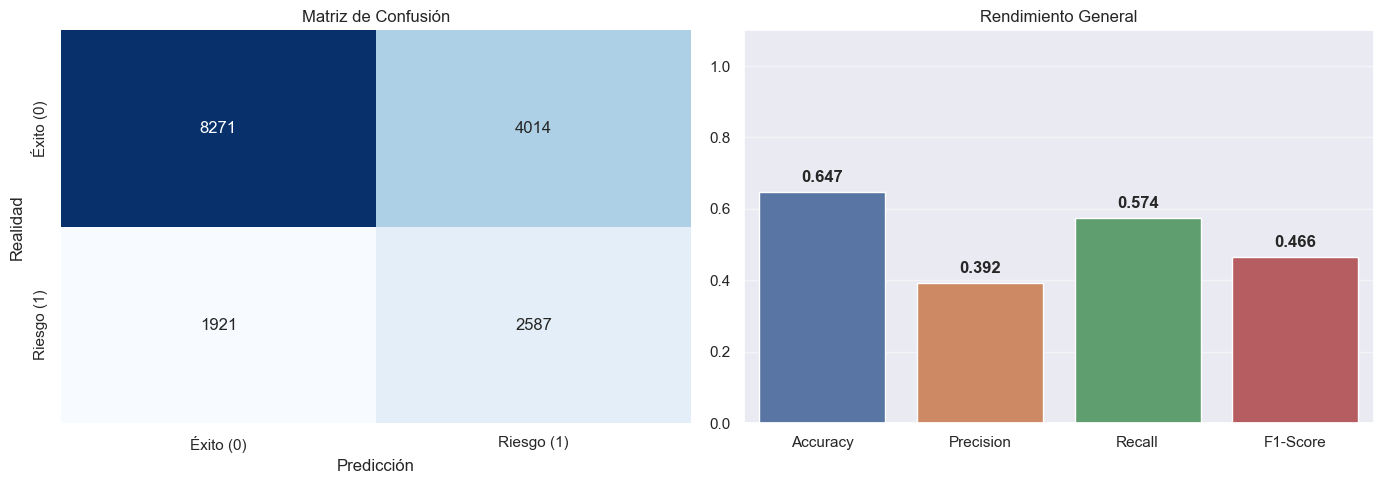

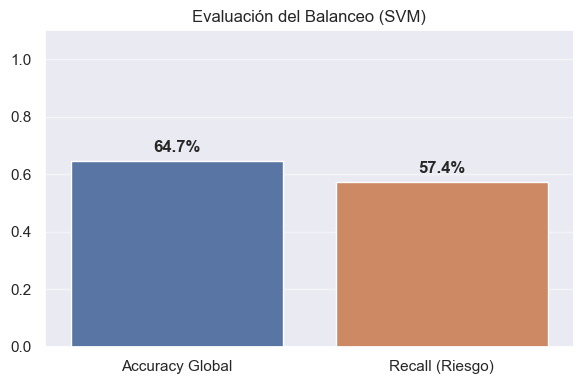

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# CÁLCULO DE MÉTRICAS Y REPORTE
# ==========================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("--- REPORTE DE CLASIFICACIÓN DETALLADO (SVM) ---")
print(classification_report(y_test, y_pred, zero_division=0))

# ==========================================
# GRÁFICOS: MÉTRICAS Y MATRIZ DE CONFUSIÓN
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=['Éxito (0)', 'Riesgo (1)'],
            yticklabels=['Éxito (0)', 'Riesgo (1)'])
ax1.set_title('Matriz de Confusión')
ax1.set_xlabel('Predicción')
ax1.set_ylabel('Realidad')

# Subplot 2: Métricas Habituales
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [acc, prec, rec, f1]
sns.barplot(x=metrics_names, y=metrics_values, hue=metrics_names, legend=False, ax=ax2)
ax2.set_title('Rendimiento General')
ax2.set_ylim(0, 1.1)

for i, v in enumerate(metrics_values):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# GRÁFICO: Accuracy vs Recall Minoritario
# ==========================================
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
burnout_recall = report_dict['1']['recall']

plt.figure(figsize=(6, 4))
metric_names_comp = ['Accuracy Global', 'Recall (Riesgo)']
metric_values_comp = [acc, burnout_recall]

ax3 = sns.barplot(x=metric_names_comp, y=metric_values_comp, hue=metric_names_comp, legend=False)
plt.title('Evaluación del Balanceo (SVM)')
plt.ylim(0, 1.1)

for i, v in enumerate(metric_values_comp):
    ax3.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()